# Enriched vs. Community Classification — Final Analysis

In [52]:

import pandas as pd
import numpy as np
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load & merge
start_data  = pd.read_csv("START.csv")
sample_data = pd.read_csv("bhisma_data.csv", usecols=['id', 'sample'])
sample_data['child_ids'] = sample_data['id'] + "-BL"
sample_data.drop(columns=['id'], inplace=True)
sample_data.rename(columns={"sample": "label"}, inplace=True)
sample_data['label'] = sample_data['label'].map({'enriched': 1, 'community': 0})

df = start_data.merge(sample_data, on='child_ids', how='inner')
df = df[df['label'].notna()].copy()

print(f"Dataset: {df.shape[0]} participants, {df.shape[1]-2} features + label")
df.head()

Dataset: 3994 participants, 17 features + label


,child_ids,Age,wt.PROP_TIME,wt.MEDIAN_DISTANCE,wt.STD_DISTANCE,plt.SOC_PROP,bt.soc_pref,mft.rmse,mft.jerk,ct.crossover_counts,bpt.mean_size,bpt.mean_euclid,bpt.time_taken,st.tapinterval_400_dist,st.tapinterval_600_dist,st.mean_resultant_length_400,st.mean_resultant_length_600,dgt.propDelay,label
0,IN-0003-BL,1296,0.082200,1.498375,-0.219560,-0.701509,-0.949465,-0.520370,-0.639603,-0.100292,-0.645318,-0.194940,-0.828485,0.753390,1.222460,1.259377,1.146804,0.902206,0
1,IN-0006-BL,1301,0.911253,0.901357,0.601351,-0.840406,-0.233458,0.650382,-0.520949,-0.294521,-0.649163,-0.033170,-0.448577,NaN,NaN,NaN,NaN,0.902206,0
2,IN-0007-BL,626,NaN,NaN,NaN,-0.862454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,IN-0011-BL,2037,0.984733,0.318470,-0.461384,0.219456,-0.233458,-0.506655,-0.649739,0.242649,-0.613434,-1.372057,-1.077061,-1.902467,-0.668754,-0.019029,0.692864,0.902206,0
4,IN-0012-BL,172,NaN,NaN,NaN,-0.848823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


## Exploratory Data Analysis

Full dataset class distribution:
label
0    3735
1     259
Name: count, dtype: int64
label
0    93.5%
1     6.5%
Name: proportion, dtype: str


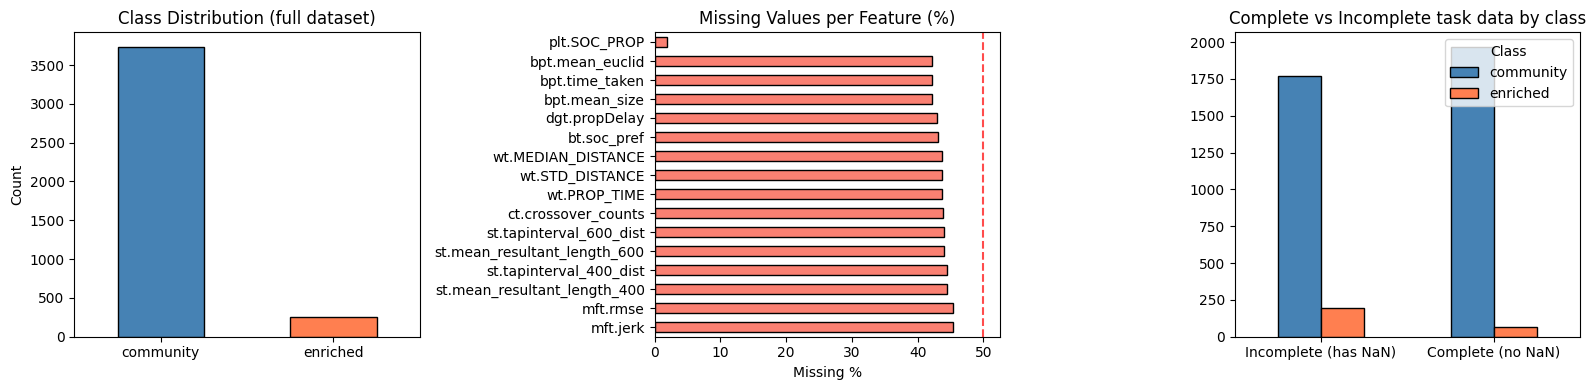


Note: ~43% of participants have NO task data (entire battery absent).
Enriched children disproportionately lack task data.
label                 community  enriched
Incomplete (has NaN)       1767       193
Complete (no NaN)          1968        66


In [53]:
print("Full dataset class distribution:")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

task_cols = [c for c in df.columns if c not in ['child_ids', 'label', 'Age']]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
df['label'].map({0: 'community', 1: 'enriched'}).value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black'
)
axes[0].set_title('Class Distribution (full dataset)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Missing values per feature
miss = df[task_cols].isnull().mean().mul(100).sort_values(ascending=False)
miss.plot(kind='barh', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Missing Values per Feature (%)')
axes[1].set_xlabel('Missing %')
axes[1].axvline(50, color='red', linestyle='--', alpha=0.7)

# How many enriched are complete vs incomplete
complete_mask = df[task_cols].notna().all(axis=1)
breakdown = pd.crosstab(complete_mask, df['label'].map({0:'community', 1:'enriched'}))
breakdown.index = ['Incomplete (has NaN)', 'Complete (no NaN)']
breakdown.plot(kind='bar', ax=axes[2], color=['steelblue', 'coral'], edgecolor='black')
axes[2].set_title('Complete vs Incomplete task data by class')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Class')

plt.tight_layout()
plt.show()

print("\nNote: ~43% of participants have NO task data (entire battery absent).")
print("Enriched children disproportionately lack task data.")
print(breakdown)

## Train / Test Split

In [54]:
# Age excluded: NDD has no age boundary and it adds <0.01 ROC-AUC
feature_cols = [c for c in df.columns if c not in ['child_ids', 'label', 'Age']]

# Drop rows where ANY task feature is missing.
# ~43% of participants have no task data at all (entire task battery absent).
# Imputing medians for them would just add noise — they can't be scored by
# this model without real task performance data.
df_model = df.dropna(subset=feature_cols).copy()

print(f"Before dropna: {len(df):,} rows  ({df['label'].sum():.0f} enriched)")
print(f"After  dropna: {len(df_model):,} rows  ({df_model['label'].sum():.0f} enriched)")
print(f"\nEnriched %  before: {df['label'].mean()*100:.1f}%")
print(f"Enriched %  after : {df_model['label'].mean()*100:.1f}%")

X = df_model[feature_cols].copy()
y = df_model['label'].copy().astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}   Test: {X_test.shape}")
print(f"Train labels:\n{y_train.value_counts()}")
print(f"\nTest labels:\n{y_test.value_counts()}")

Before dropna: 3,994 rows  (259 enriched)
After  dropna: 2,034 rows  (66 enriched)

Enriched %  before: 6.5%
Enriched %  after : 3.2%

Train: (1627, 16)   Test: (407, 16)
Train labels:
label
0    1574
1      53
Name: count, dtype: int64

Test labels:
label
0    394
1     13
Name: count, dtype: int64


## SMOTE + Pipelines

SMOTE generates **synthetic** minority samples by interpolating between real minority neighbours.  Applied **inside each pipeline** so it only fires during `fit()` and is isolated in CV folds.

The `SimpleImputer` is kept as a safety net for the few residual NaN values in `plt.SOC_PROP` (~2%); for all other features the data is already complete after `dropna`.

In [55]:
lr_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('smote',   SMOTE(random_state=42)),
    ('clf',     LogisticRegression(random_state=42, max_iter=1000, C=1.0)),
])

rf_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote',   SMOTE(random_state=42)),
    ('clf',     RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
])

gb_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote',   SMOTE(random_state=42)),
    ('clf',     GradientBoostingClassifier(
                    n_estimators=200, learning_rate=0.05,
                    max_depth=3, random_state=42)),
])

print("Pipelines defined:")
print("  LR : Impute → Scale → SMOTE → LogisticRegression")
print("  RF : Impute → SMOTE → RandomForest")
print("  GB : Impute → SMOTE → GradientBoosting")

Pipelines defined:
  LR : Impute → Scale → SMOTE → LogisticRegression
  RF : Impute → SMOTE → RandomForest
  GB : Impute → SMOTE → GradientBoosting


## Model Training

In [56]:
models = {
    'Logistic Regression': lr_pipe,
    'Random Forest':       rf_pipe,
    'Gradient Boosting':   gb_pipe,
}

fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]
    print(f"\n{'='*52}\n  {name}\n{'='*52}")
    print(classification_report(y_test, pred, target_names=['community', 'enriched']))
    print(f"  ROC-AUC (test): {roc_auc_score(y_test, prob):.3f}")


  Logistic Regression
              precision    recall  f1-score   support

   community       0.98      0.75      0.85       394
    enriched       0.08      0.62      0.13        13

    accuracy                           0.75       407
   macro avg       0.53      0.68      0.49       407
weighted avg       0.95      0.75      0.83       407

  ROC-AUC (test): 0.767

  Random Forest
              precision    recall  f1-score   support

   community       0.97      0.95      0.96       394
    enriched       0.10      0.15      0.12        13

    accuracy                           0.93       407
   macro avg       0.54      0.55      0.54       407
weighted avg       0.94      0.93      0.94       407

  ROC-AUC (test): 0.785

  Gradient Boosting
              precision    recall  f1-score   support

   community       0.98      0.92      0.95       394
    enriched       0.14      0.38      0.20        13

    accuracy                           0.90       407
   macro avg       

## Confusion Matrices & Cross-Validation

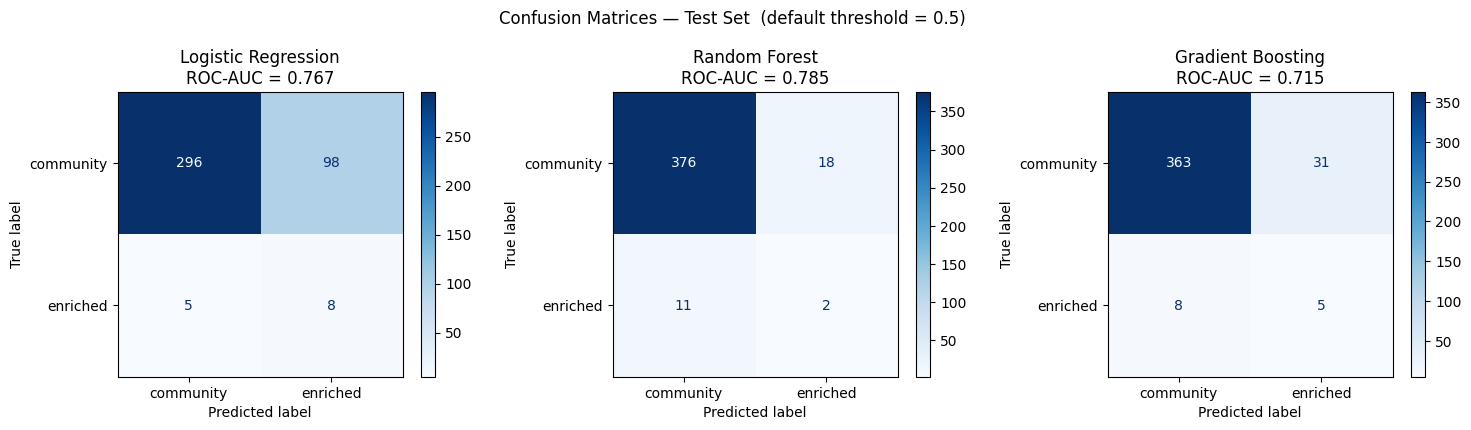


5-fold Stratified CV  ROC-AUC:
  Logistic Regression       0.774 ± 0.049
  Random Forest             0.754 ± 0.049
  Gradient Boosting         0.696 ± 0.075


In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, fitted.items()):
    pred = pipe.predict(X_test)
    auc  = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=['community', 'enriched'],
        ax=ax, cmap='Blues'
    )
    ax.set_title(f"{name}\nROC-AUC = {auc:.3f}")
plt.suptitle("Confusion Matrices — Test Set  (default threshold = 0.5)", y=1.02)
plt.tight_layout()
plt.show()

# 5-fold stratified CV ROC-AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n5-fold Stratified CV  ROC-AUC:")
for name, pipe in fitted.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    print(f"  {name:<25} {scores.mean():.3f} ± {scores.std():.3f}")

## Feature Importance — Logistic Regression Coefficients

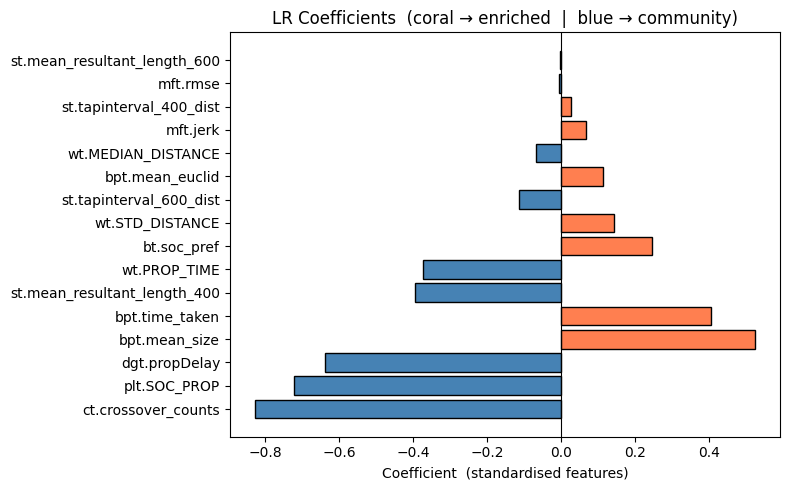


Features → enriched  (positive):
                feature  coefficient
          bpt.mean_size     0.523542
         bpt.time_taken     0.404399
            bt.soc_pref     0.244266
        wt.STD_DISTANCE     0.143504
        bpt.mean_euclid     0.111811
               mft.jerk     0.066026
st.tapinterval_400_dist     0.026397

Features → community  (negative):
                     feature  coefficient
         ct.crossover_counts    -0.827969
                plt.SOC_PROP    -0.723273
               dgt.propDelay    -0.638051
st.mean_resultant_length_400    -0.394956
                wt.PROP_TIME    -0.373791
     st.tapinterval_600_dist    -0.112893
          wt.MEDIAN_DISTANCE    -0.067467
                    mft.rmse    -0.004871
st.mean_resultant_length_600    -0.003655


In [58]:
coef = lr_pipe.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': coef})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 5))
colors = ['coral' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('LR Coefficients  (coral → enriched  |  blue → community)')
plt.xlabel('Coefficient  (standardised features)')
plt.tight_layout()
plt.show()

print("\nFeatures → enriched  (positive):")
print(coef_df[coef_df['coefficient'] > 0][['feature', 'coefficient']].to_string(index=False))
print("\nFeatures → community  (negative):")
print(coef_df[coef_df['coefficient'] < 0][['feature', 'coefficient']].to_string(index=False))

## Threshold Optimisation — Logistic Regression

Default threshold of 0.5 is wrong for a 30:1 imbalance. Optimal threshold found by maximising F1 for the enriched class on the Precision-Recall curve.

Optimal threshold: 0.976

--- LR at tuned threshold (0.98) ---
              precision    recall  f1-score   support

   community       0.98      0.99      0.98       394
    enriched       0.60      0.23      0.33        13

    accuracy                           0.97       407
   macro avg       0.79      0.61      0.66       407
weighted avg       0.96      0.97      0.96       407



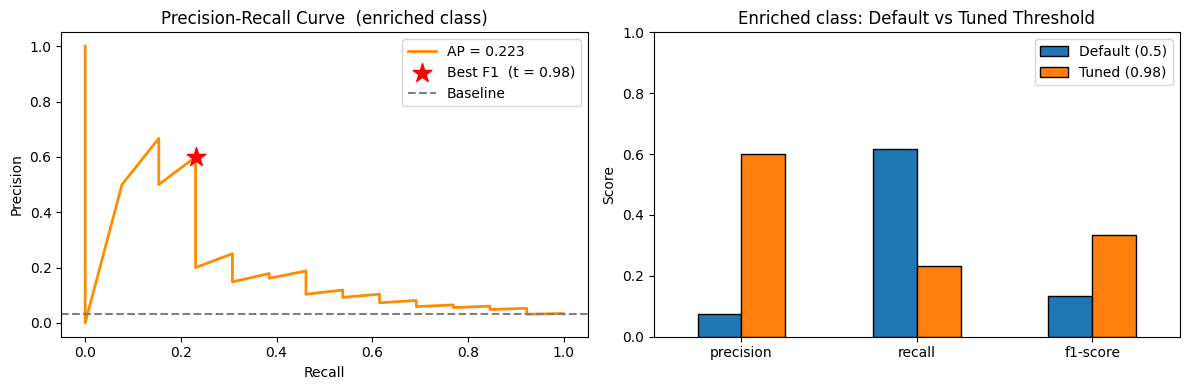

In [59]:
lr_prob = lr_pipe.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, lr_prob)
f1_scores  = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx   = np.argmax(f1_scores)
best_t     = thresholds[best_idx]

y_pred_tuned = (lr_prob >= best_t).astype(int)
print(f"Optimal threshold: {best_t:.3f}")
print(f"\n--- LR at tuned threshold ({best_t:.2f}) ---")
print(classification_report(y_test, y_pred_tuned, target_names=['community', 'enriched']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ap = average_precision_score(y_test, lr_prob)
ax1.plot(recalls, precisions, color='darkorange', lw=2, label=f'AP = {ap:.3f}')
ax1.scatter(recalls[best_idx], precisions[best_idx], marker='*', s=200,
            color='red', zorder=5, label=f'Best F1  (t = {best_t:.2f})')
ax1.axhline(sum(y_test) / len(y_test), color='gray', linestyle='--', label='Baseline')
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve  (enriched class)')
ax1.legend()

lr_pred_default = lr_pipe.predict(X_test)
comp = pd.DataFrame({
    'Default (0.5)': classification_report(y_test, lr_pred_default, output_dict=True)['1'],
    f'Tuned ({best_t:.2f})': classification_report(y_test, y_pred_tuned, output_dict=True)['1'],
}).loc[['precision', 'recall', 'f1-score']]
comp.plot(kind='bar', ax=ax2, edgecolor='black')
ax2.set_title('Enriched class: Default vs Tuned Threshold')
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=0)
ax2.legend()
plt.tight_layout()
plt.show()

## Model Comparison Summary

In [60]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = {}
for name, pipe in fitted.items():
    pred   = pipe.predict(X_test)
    prob   = pipe.predict_proba(X_test)[:, 1]
    cv_roc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    rep    = classification_report(y_test, pred, output_dict=True)
    rows[name] = {
        'ROC-AUC (test)':     round(roc_auc_score(y_test, prob), 3),
        'CV ROC-AUC':         f"{cv_roc.mean():.3f} ± {cv_roc.std():.3f}",
        'Enriched Precision': round(rep['1']['precision'], 3),
        'Enriched Recall':    round(rep['1']['recall'],    3),
        'Enriched F1':        round(rep['1']['f1-score'],  3),
    }

# LR with tuned threshold
lr_prob_all = lr_pipe.predict_proba(X_test)[:, 1]
prec_c, rec_c, thr_c = precision_recall_curve(y_test, lr_prob_all)
f1_c   = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-8)
best_t = thr_c[np.argmax(f1_c)]
y_tuned = (lr_prob_all >= best_t).astype(int)
rep_t   = classification_report(y_test, y_tuned, output_dict=True)
rows[f'LR  (tuned  t={best_t:.2f})'] = {
    'ROC-AUC (test)':     round(roc_auc_score(y_test, lr_prob_all), 3),
    'CV ROC-AUC':         '—',
    'Enriched Precision': round(rep_t['1']['precision'], 3),
    'Enriched Recall':    round(rep_t['1']['recall'],    3),
    'Enriched F1':        round(rep_t['1']['f1-score'],  3),
}

summary = pd.DataFrame(rows).T
print(summary.to_string())
summary

                    ROC-AUC (test)     CV ROC-AUC Enriched Precision Enriched Recall Enriched F1
Logistic Regression          0.767  0.774 ± 0.049              0.075           0.615       0.134
Random Forest                0.785  0.754 ± 0.049                0.1           0.154       0.121
Gradient Boosting            0.715  0.696 ± 0.075              0.139           0.385       0.204
LR  (tuned  t=0.98)          0.767              —                0.6           0.231       0.333


,ROC-AUC (test),CV ROC-AUC,Enriched Precision,Enriched Recall,Enriched F1
Logistic Regression,0.767,0.774 ± 0.049,0.075,0.615,0.134
Random Forest,0.785,0.754 ± 0.049,0.1,0.154,0.121
Gradient Boosting,0.715,0.696 ± 0.075,0.139,0.385,0.204
LR (tuned t=0.98),0.767,—,0.6,0.231,0.333
